# Gene Expression Analysis of Breast Cancer by ER Status

## 01 — Data Exploration and Differential Expression

### Objective

The aim of this analysis is to investigate whether gene expression
profiles differ between estrogen receptor-positive (ER+) and
estrogen receptor-negative (ER−) breast cancer samples.

This notebook focuses on data preparation, exploratory analysis,
dimensionality reduction, and differential gene expression analysis.

### Analysis workflow

1. Load and inspect clinical and gene expression data.
2. Identify samples shared between clinical and expression datasets.
3. Define ER status and perform data quality checks.
4. Handle missing values and duplicated gene identifiers.
5. Explore the global structure of gene expression using Principal
   Component Analysis (PCA).
6. Identify genes contributing to the main expression patterns.
7. Compare gene expression between ER+ and ER− samples using
   the Mann–Whitney U test.
8. Correct for multiple testing using the Benjamini–Hochberg
   false discovery rate (FDR).
9. Visualize differential expression using a volcano plot.
10. Identify a set of genes showing both statistical significance
    and a meaningful difference in expression.

### Key questions

- Do ER+ and ER− breast cancer samples show distinct global
  gene expression patterns?
- Which genes contribute most to the observed separation?
- Which genes are differentially expressed between ER+ and ER− samples?
- How many genes show both statistical significance and a substantial
  difference in expression?

### Dataset

The analysis uses matched clinical and gene expression data from
breast cancer samples. After matching the datasets and applying the
quality-control steps, 519 samples were retained for analysis.

The final dataset contains:

- 401 ER+ samples
- 118 ER− samples
- 17,264 unique genes

### Main findings

The PCA revealed a clear separation between ER+ and ER− samples
along the first principal component. Genes such as **ESR1**, **GATA3**,
and **FOXA1** contributed strongly to this pattern and showed markedly
higher expression in ER+ samples.

Differential expression analysis identified a large number of genes
with statistically significant differences between the two groups.
To focus on genes with both statistical evidence and a meaningful
effect size, genes were selected using:

- FDR < 0.05
- Absolute mean expression difference ≥ 1

This resulted in a set of 950 candidate genes for downstream analysis.

### Next step

The selected expression features will be investigated in a separate
machine-learning notebook to evaluate whether gene expression can be
used to predict ER status in previously unseen samples.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
clinical = pd.read_csv(
    "../data/raw/data_clinical_sample.txt",
    sep="\t"
)

clinical

,#Sample Identifier,Patient Identifier,ER Status,PR Status,HER2 Status,Tumor Stage,Tumor--T1 Coded,Node,Node-Coded,Metastasis-Coded,...,CN Cluster,Integrated Clusters (with PAM50),Integrated Clusters (no exp),Integrated Clusters (unsup exp),Cancer Type Detailed,Oncotree Code,Cancer Type,Sample Type,Somatic Status,TMB (nonsynonymous)
0,#A unique sample identifier.,Identifier to uniquely specify a patient.,ER Status,PR Status,HER2 Status,Tumor stage.,Tumor--T1 Coded,Node,Node-Coded,Metastasis-Coded,...,CN cluster.,Integrated Clusters (with PAM50),Integrated Clusters (no exp),Integrated Clusters (unsup exp),Cancer Type Detailed,Oncotree Code,Cancer Type,"The type of sample (i.e., normal, primary, met...",Somatic Status,TMB (nonsynonymous)
1,#STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,...,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,STRING,NUMBER
2,#1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,9,1,1
3,SAMPLE_ID,PATIENT_ID,ER_STATUS,PR_STATUS,HER2_STATUS,TUMOR_STAGE,TUMOR_T1_CODED,NODES,NODE_CODED,METASTASIS_CODED,...,CN_CLUSTER,INTEGRATED_CLUSTERS_WITH_PAM50,INTEGRATED_CLUSTERS_NO_EXP,INTEGRATED_CLUSTERS_UNSUP_EXP,CANCER_TYPE_DETAILED,ONCOTREE_CODE,CANCER_TYPE,SAMPLE_TYPE,SOMATIC_STATUS,TMB_NONSYNONYMOUS
4,TCGA-A2-A0T2-01,TCGA-A2-A0T2,Negative,Negative,Negative,T3,T_Other,N3,Positive,Positive,...,3,2,2,2,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,0.766666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
824,TCGA-AC-A2FF-01,TCGA-AC-A2FF,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1,NaN,NaN,NaN,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,NaN
825,TCGA-AC-A2FB-01,TCGA-AC-A2FB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,NaN
826,TCGA-AC-A2FG-01,TCGA-AC-A2FG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,NaN,NaN,NaN,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,NaN
827,TCGA-GI-A2C8-01,TCGA-GI-A2C8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3,NaN,NaN,NaN,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,NaN


In [3]:
clinical.shape

(829, 28)

In [4]:
clinical.columns.tolist()

['#Sample Identifier',
 'Patient Identifier',
 'ER Status',
 'PR Status',
 'HER2 Status',
 'Tumor Stage',
 'Tumor--T1 Coded',
 'Node',
 'Node-Coded',
 'Metastasis-Coded',
 'Converted Stage',
 'Survival Data Form',
 'PAM50 subtype',
 'SigClust Unsupervised mRNA',
 'SigClust Intrinsic mRNA',
 'MIRNA Cluster',
 'Methylation Cluster',
 'RPPA Cluster',
 'CN Cluster',
 'Integrated Clusters (with PAM50)',
 'Integrated Clusters (no exp)',
 'Integrated Clusters (unsup exp)',
 'Cancer Type Detailed',
 'Oncotree Code',
 'Cancer Type',
 'Sample Type',
 'Somatic Status',
 'TMB (nonsynonymous)']

In [5]:
clinical["ER Status"].value_counts(dropna=False)

ER Status
Positive                       601
Negative                       179
Not Performed                   31
NaN                              7
Performed but Not Available      5
Indeterminate                    2
ER Status                        1
STRING                           1
1                                1
ER_STATUS                        1
Name: count, dtype: int64

In [6]:
clinical["#Sample Identifier"].nunique()

829

In [7]:
clinical = clinical[clinical["ER Status"].isin(["Positive", "Negative"])].copy()
clinical["ER Status"].value_counts()

ER Status
Positive    601
Negative    179
Name: count, dtype: int64

In [8]:
clinical

,#Sample Identifier,Patient Identifier,ER Status,PR Status,HER2 Status,Tumor Stage,Tumor--T1 Coded,Node,Node-Coded,Metastasis-Coded,...,CN Cluster,Integrated Clusters (with PAM50),Integrated Clusters (no exp),Integrated Clusters (unsup exp),Cancer Type Detailed,Oncotree Code,Cancer Type,Sample Type,Somatic Status,TMB (nonsynonymous)
4,TCGA-A2-A0T2-01,TCGA-A2-A0T2,Negative,Negative,Negative,T3,T_Other,N3,Positive,Positive,...,3,2,2,2,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,0.766666667
5,TCGA-A2-A04P-01,TCGA-A2-A04P,Negative,Negative,Negative,T2,T_Other,N3,Positive,Negative,...,1,2,2,2,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,3.4
6,TCGA-A1-A0SK-01,TCGA-A1-A0SK,Negative,Negative,Negative,T2,T_Other,N0,Negative,Negative,...,1,2,2,2,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,1.6
7,TCGA-A2-A0CM-01,TCGA-A2-A0CM,Negative,Negative,Negative,T2,T_Other,N0,Negative,Negative,...,4,2,1,1,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,1.233333333
8,TCGA-AR-A1AR-01,TCGA-AR-A1AR,Negative,Negative,Negative,T1,T1,N2,Positive,Negative,...,1,NaN,NaN,NaN,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,1.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
817,TCGA-GM-A2DK-01,TCGA-GM-A2DK,Positive,Negative,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,NaN
818,TCGA-GM-A2DL-01,TCGA-GM-A2DL,Positive,Positive,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,NaN
819,TCGA-GM-A2DM-01,TCGA-GM-A2DM,Positive,Positive,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,NaN
820,TCGA-GM-A2DN-01,TCGA-GM-A2DN,Positive,Positive,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Invasive Breast Carcinoma,BRCA,Breast Cancer,Primary,Matched,NaN


In [9]:
expression = pd.read_csv(
    "../data/raw/data_mrna_agilent_microarray.txt",
    sep="\t"
)
expression

,Hugo_Symbol,Entrez_Gene_Id,TCGA-A1-A0SD-01,TCGA-A1-A0SE-01,TCGA-A1-A0SH-01,TCGA-A1-A0SJ-01,TCGA-A1-A0SK-01,TCGA-A1-A0SM-01,TCGA-A1-A0SO-01,TCGA-A1-A0SP-01,...,TCGA-E2-A15S-01,TCGA-E2-A15T-01,TCGA-E2-A1AZ-01,TCGA-E2-A1B0-01,TCGA-E2-A1B1-01,TCGA-E2-A1B4-01,TCGA-E2-A1B5-01,TCGA-E2-A1B6-01,TCGA-E2-A1BC-01,TCGA-E2-A1BD-01
0,CREB3L1,90993,1.43450,0.890750,2.259250,0.437750,-0.637250,2.58000,-0.70750,0.16675,...,0.20625,0.337500,0.428250,0.968250,1.89825,1.718250,-0.071750,1.400250,1.630250,0.46525
1,RPS11,6205,0.76500,0.716000,0.417125,0.115000,0.492875,-0.52500,-0.16900,0.39600,...,-0.32875,-0.438625,0.781000,0.226875,0.35225,0.326125,0.603625,1.406625,0.649750,0.60075
2,PNMA1,9240,0.52600,0.131750,0.325000,0.757750,0.943250,0.64175,-0.06425,0.02600,...,0.14925,1.009250,-0.209250,-0.036750,0.50025,-0.363500,-1.244500,-0.421250,-0.449750,-0.20225
3,MMP2,4313,1.50600,0.957833,2.285500,-0.089333,-1.233167,1.59150,-1.39650,-0.26050,...,-1.56750,0.123000,1.544167,1.279167,2.48400,0.400667,-1.006000,-0.217167,1.637167,1.50500
4,C10orf90,118611,-2.01825,-0.590250,-1.726750,-1.783750,-2.755000,-1.86975,-2.27500,-2.13350,...,-2.24150,-1.759500,-1.477500,-1.967250,-1.91425,-1.726250,0.951500,-1.404500,-2.238750,-1.25525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17263,PIK3IP1,113791,1.96725,2.810750,2.369500,2.857250,1.860000,2.63200,1.69450,1.23125,...,1.01800,1.911250,1.343750,2.120500,3.24200,2.251000,2.799500,3.444000,2.835750,1.53675
17264,SLC39A6,25800,0.66450,2.073600,0.501300,3.096700,-0.428800,0.74690,-1.48740,-1.45310,...,4.15930,1.815700,-2.070000,-1.349900,-1.26510,2.228200,-2.616100,1.931500,0.018400,1.89070
17265,SNRPD2,6633,0.07660,-0.067500,-0.196300,0.332100,0.004800,-0.75400,0.55480,0.11760,...,-0.34120,-0.533500,1.005600,-0.053400,-1.07570,0.145900,0.574100,0.316800,-0.567200,0.16680
17266,AQP7,364,-0.65600,-1.009500,-1.076500,1.591000,-1.027500,-1.01400,-0.98150,-0.57200,...,0.58700,-0.189500,-1.264500,-0.068500,1.20350,-0.656500,-0.220000,1.678000,3.536000,-0.31100


In [10]:
expression_samples = expression.columns[2:]
clinical_samples = clinical["#Sample Identifier"]
common_samples = set(expression_samples) & set(clinical_samples)

len(common_samples)

519

In [11]:
len(expression_samples)

526

In [12]:
len(clinical_samples)

780

In [13]:
clinical_common = clinical[
    clinical["#Sample Identifier"].isin(common_samples)
].copy()

clinical_common["ER Status"].value_counts()

ER Status
Positive    401
Negative    118
Name: count, dtype: int64

In [14]:
clinical_common.shape

(519, 28)

In [15]:
clinical_er = clinical_common[
    ["#Sample Identifier", "ER Status"]
].copy()

clinical_er.head()

,#Sample Identifier,ER Status
4,TCGA-A2-A0T2-01,Negative
5,TCGA-A2-A04P-01,Negative
6,TCGA-A1-A0SK-01,Negative
7,TCGA-A2-A0CM-01,Negative
8,TCGA-AR-A1AR-01,Negative


In [16]:
expression.shape

(17268, 528)

In [17]:
expression.iloc[:, :5].head()

,Hugo_Symbol,Entrez_Gene_Id,TCGA-A1-A0SD-01,TCGA-A1-A0SE-01,TCGA-A1-A0SH-01
0,CREB3L1,90993,1.43450,0.890750,2.259250
1,RPS11,6205,0.76500,0.716000,0.417125
2,PNMA1,9240,0.52600,0.131750,0.325000
3,MMP2,4313,1.50600,0.957833,2.285500
4,C10orf90,118611,-2.01825,-0.590250,-1.726750


In [18]:
expression["Hugo_Symbol"].duplicated().sum()

np.int64(4)

In [19]:
expression["Entrez_Gene_Id"].duplicated().sum()

np.int64(35)

In [20]:
expression[
    expression["Hugo_Symbol"].duplicated(keep=False)
][["Hugo_Symbol", "Entrez_Gene_Id"]]

,Hugo_Symbol,Entrez_Gene_Id
1675,TCP10L,140290
5344,C20orf96,140680
6277,SFTPA1,653509
7113,TCP10L,140290
7167,RBM14,10432
9211,SFTPA1,653509
15129,RBM14,10432
15756,C20orf96,140680


In [21]:
expression[
    expression["Entrez_Gene_Id"].duplicated(keep=False)
][["Hugo_Symbol", "Entrez_Gene_Id"]].sort_values("Entrez_Gene_Id")

,Hugo_Symbol,Entrez_Gene_Id
12932,C9orf47,1903
15001,EDG3,1903
812,MDS1,2122
7788,EVI1,2122
12117,KRTHB5,3891
...,...,...
13557,DCDC1,341019
13250,PALM2-AKAP2,445815
11017,PALM2AKAP2,445815
9211,SFTPA1,653509


## Data preparation

The clinical and gene expression datasets have been matched using the sample identifier.

Before downstream analysis, the expression matrix is reorganized so that samples are represented as rows and genes as columns. Missing expression values are median-imputed to allow subsequent dimensionality reduction and statistical analysis.

Duplicated gene identifiers are examined and handled before differential expression analysis.

In [22]:
expression_values = expression.iloc[:, 2:].copy()

expression_values.index = expression["Hugo_Symbol"]

expression_t = expression_values.T

expression_t.index.name = "#Sample Identifier"

expression_t = expression_t.reset_index()

expression_t.columns.name = None

expression_t.shape

(526, 17269)

In [23]:
expression_t

,#Sample Identifier,CREB3L1,RPS11,PNMA1,MMP2,C10orf90,ZHX3,ERCC5,GPR98,RXFP3,...,SLC2A11,GRIP2,GPLD1,RAB8A,RXFP2,PIK3IP1,SLC39A6,SNRPD2,AQP7,CTSC
0,TCGA-A1-A0SD-01,1.43450,0.765000,0.52600,1.506000,-2.01825,0.043333,-0.10725,0.103125,-0.0620,...,0.280333,-0.25000,-0.667167,-0.0308,0.3870,1.96725,0.6645,0.0766,-0.6560,-0.9941
1,TCGA-A1-A0SE-01,0.89075,0.716000,0.13175,0.957833,-0.59025,-0.043667,-0.23850,-0.152250,0.4425,...,0.185833,-0.18750,-0.440000,0.5352,0.2570,2.81075,2.0736,-0.0675,-1.0095,-1.1553
2,TCGA-A1-A0SH-01,2.25925,0.417125,0.32500,2.285500,-1.72675,0.420500,0.00725,-0.696000,0.2960,...,-0.001333,-0.26900,-0.996667,0.8484,0.6025,2.36950,0.5013,-0.1963,-1.0765,-0.7658
3,TCGA-A1-A0SJ-01,0.43775,0.115000,0.75775,-0.089333,-1.78375,0.251000,0.03525,-0.640625,0.6885,...,0.455333,0.00025,-0.099500,0.1940,-0.1235,2.85725,3.0967,0.3321,1.5910,-0.7459
4,TCGA-A1-A0SK-01,-0.63725,0.492875,0.94325,-1.233167,-2.75500,-1.331500,0.79100,0.014500,-0.0600,...,-0.669333,-0.11650,-0.634167,0.8949,0.0855,1.86000,-0.4288,0.0048,-1.0275,-0.6338
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521,TCGA-E2-A1B4-01,1.71825,0.326125,-0.36350,0.400667,-1.72625,0.604333,0.70850,1.288375,-0.2805,...,0.290333,0.01850,-2.196000,-0.4175,0.8970,2.25100,2.2282,0.1459,-0.6565,-0.7379
522,TCGA-E2-A1B5-01,-0.07175,0.603625,-1.24450,-1.006000,0.95150,-0.852833,1.27775,-1.034375,0.7400,...,-0.246500,0.17250,-0.565000,0.3801,0.7310,2.79950,-2.6161,0.5741,-0.2200,0.5551
523,TCGA-E2-A1B6-01,1.40025,1.406625,-0.42125,-0.217167,-1.40450,-0.569167,0.91700,1.048000,-0.0150,...,-0.418500,-0.30950,-0.307000,0.2461,2.2565,3.44400,1.9315,0.3168,1.6780,0.6586
524,TCGA-E2-A1BC-01,1.63025,0.649750,-0.44975,1.637167,-2.23875,-0.101833,0.40550,1.533000,-0.5785,...,-0.079333,-0.71800,-1.892667,0.8770,0.1270,2.83575,0.0184,-0.5672,3.5360,-1.1423


In [24]:
expression_t.columns[:5]

Index(['#Sample Identifier', 'CREB3L1', 'RPS11', 'PNMA1', 'MMP2'], dtype='object')

In [25]:
len(
    set(expression_t["#Sample Identifier"]) &
    set(clinical_er["#Sample Identifier"])
)

519

In [26]:
dataset = clinical_er.merge(
    expression_t,
    on="#Sample Identifier",
    how="inner"
)

dataset.shape

(519, 17270)

In [27]:
dataset["ER Status"].value_counts()

ER Status
Positive    401
Negative    118
Name: count, dtype: int64

In [28]:
dataset

,#Sample Identifier,ER Status,CREB3L1,RPS11,PNMA1,MMP2,C10orf90,ZHX3,ERCC5,GPR98,...,SLC2A11,GRIP2,GPLD1,RAB8A,RXFP2,PIK3IP1,SLC39A6,SNRPD2,AQP7,CTSC
0,TCGA-A2-A0T2-01,Negative,0.76050,0.349125,-0.83450,-0.166000,-1.26175,-0.189000,-0.31475,-1.475250,...,0.772667,0.03325,-0.945667,0.2620,0.9770,0.89500,-0.8492,0.1878,-1.4735,-0.6457
1,TCGA-A2-A04P-01,Negative,0.96650,0.400875,-1.72625,-0.716333,1.33675,-0.253833,0.42300,-0.235625,...,-0.626333,-0.01050,-0.967000,1.2088,0.9995,0.51000,-3.7138,0.4483,0.0825,0.3699
2,TCGA-A1-A0SK-01,Negative,-0.63725,0.492875,0.94325,-1.233167,-2.75500,-1.331500,0.79100,0.014500,...,-0.669333,-0.11650,-0.634167,0.8949,0.0855,1.86000,-0.4288,0.0048,-1.0275,-0.6338
3,TCGA-A2-A0CM-01,Negative,0.30725,0.285625,0.14875,0.397667,-2.02925,-0.471000,-0.69800,-2.591143,...,-0.677167,-0.04975,-1.223333,0.1969,0.7275,1.53775,-2.2197,0.3574,-1.3070,0.1510
4,TCGA-AR-A1AR-01,Negative,0.61075,0.943000,0.03950,1.001833,-1.37600,-0.957667,-0.16775,-1.254250,...,-0.402500,-0.63775,-0.595167,0.1063,0.8205,1.70050,-2.3945,0.2100,1.6350,1.0523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
514,TCGA-A1-A0SP-01,Negative,0.16675,0.396000,0.02600,-0.260500,-2.13350,-1.090667,-0.56675,-1.448500,...,-0.130833,-0.30950,-0.811500,0.3926,-0.3370,1.23125,-1.4531,0.1176,-0.5720,0.5423
515,TCGA-A8-A08S-01,Positive,1.20900,-0.380750,0.69150,-0.096833,-2.23050,0.555833,-0.17825,-0.779000,...,0.254333,-0.55275,-0.246667,0.8413,0.4120,2.66000,4.5334,-0.2355,-0.8325,-1.1572
516,TCGA-A8-A09E-01,Positive,0.49400,0.135500,-1.17075,0.230000,-2.33975,0.037167,-0.02850,-2.483375,...,-0.141167,0.02500,-0.623000,0.5944,0.2335,2.24250,3.0699,0.5475,0.3285,-1.1917
517,TCGA-A8-A09K-01,Positive,-1.17575,-0.037875,0.35675,-1.344000,-1.93300,0.798167,-0.20900,-1.022375,...,0.778167,-0.04775,-0.128000,0.4229,1.4655,3.28400,2.6583,-0.3320,-0.4915,-0.2277


In [29]:
dataset["#Sample Identifier"].duplicated().sum()

np.int64(0)

In [30]:
dataset["ER Status"].isna().sum()

np.int64(0)

In [31]:
expression_data = dataset.drop(
    columns=["#Sample Identifier", "ER Status"]
)

expression_data.isna().sum().describe()

count    17268.000000
mean         0.081828
std          0.671477
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         16.000000
dtype: float64

In [32]:
expression_data.isna().sum().sum()

np.int64(1413)

In [33]:
missing_per_gene = expression_data.isna().sum()

missing_per_gene[missing_per_gene > 0].sort_values(ascending=False).head(20)

LCE1B        16
LHX5         16
ADAM5P       15
OR1J4        14
OR4F15       13
CCDC140      13
RPE65        13
OR4N5        12
SYT14L       12
LIPF         11
DEFB127      11
MAGEB3       11
OR10AG1      11
RPTN         11
OR10A3       11
C14orf177    11
G30          10
RLBP1L2      10
LOC554174    10
TAS2R38       9
dtype: int64

In [34]:
missing_per_gene[missing_per_gene > 0].value_counts().sort_index()

1     184
2      92
3      51
4      32
5      25
6      25
7      20
8       8
9       6
10      3
11      7
12      2
13      3
14      1
15      1
16      2
Name: count, dtype: int64

In [35]:
missing_per_sample = expression_data.isna().sum(axis=1)

missing_per_sample.describe()

count    519.000000
mean       2.722543
std        5.580241
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max       54.000000
dtype: float64

In [36]:
missing_per_sample[missing_per_sample > 0].sort_values(ascending=False).head(20)

399    54
505    39
323    34
223    33
231    31
304    26
11     24
256    23
481    23
376    23
7      20
375    18
202    18
14     18
498    18
378    17
224    17
151    17
450    16
320    16
dtype: int64

In [37]:
expression_data.dtypes.value_counts()

float64    17268
Name: count, dtype: int64

In [38]:
expression_data.iloc[:, :10].describe().loc[["min", "max", "mean", "std"]]

,CREB3L1,RPS11,PNMA1,MMP2,C10orf90,ZHX3,ERCC5,GPR98,RXFP3,APBB2
min,-1.412750,-1.025875,-1.726250,-2.284667,-5.026750,-1.737500,-1.511250,-2.807000,-1.200000,-1.636250
max,3.220250,2.522000,1.600500,2.801167,2.572500,1.361667,1.941750,2.381429,2.553000,3.444000
mean,0.920574,0.401060,0.033880,0.371425,-1.723997,-0.214435,0.038139,-0.395976,0.451887,1.237164
std,0.809879,0.497460,0.612228,0.960112,0.908379,0.477008,0.494476,1.156654,0.357677,0.860627


In [39]:
missing_by_er = expression_data.isna().sum(axis=1)

pd.DataFrame({
    "ER Status": dataset["ER Status"],
    "Missing genes": missing_by_er
}).groupby("ER Status")["Missing genes"].describe()

,count,mean,std,min,25%,50%,75%,max
ER Status,,,,,,,,
Negative,118.0,2.355932,5.484283,0.0,0.0,0.0,2.0,39.0
Positive,401.0,2.830424,5.610363,0.0,0.0,1.0,3.0,54.0


In [40]:
expression_imputed = expression_data.copy()

expression_imputed = expression_imputed.fillna(
    expression_imputed.median()
)

expression_imputed.isna().sum().sum()

np.int64(0)

## Principal Component Analysis

Principal Component Analysis (PCA) is used to explore the global structure of the gene expression data.

Because the dataset contains thousands of genes, PCA reduces the dimensionality of the expression matrix to a small number of components while retaining as much variation as possible.

The first two principal components are visualized to assess whether ER-positive and ER-negative samples show distinct expression patterns.

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()

expression_scaled = scaler.fit_transform(expression_imputed)

In [42]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(expression_scaled)

pca.explained_variance_ratio_

array([0.0855957 , 0.05412663])

In [43]:
pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2"]
)

pca_df["ER Status"] = dataset["ER Status"].values

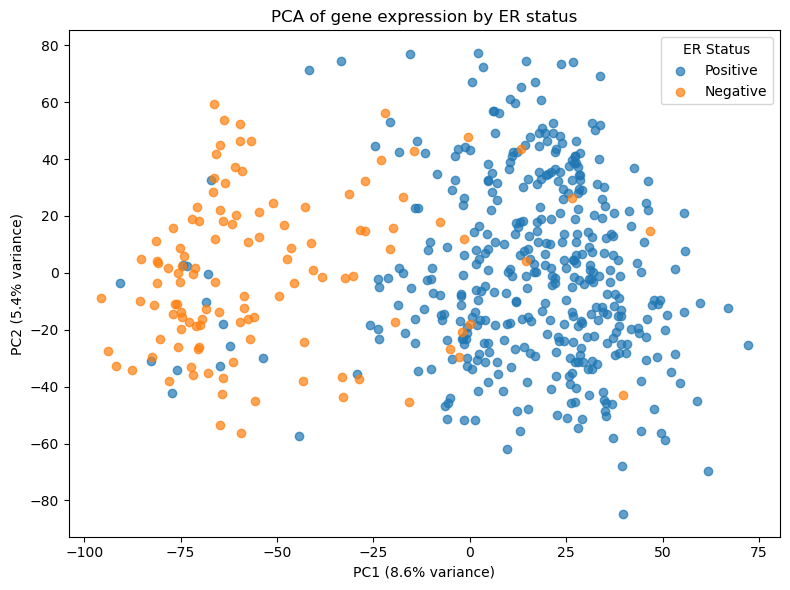

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for status in ["Positive", "Negative"]:
    subset = pca_df[pca_df["ER Status"] == status]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=status,
        alpha=0.7
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.title("PCA of gene expression by ER status")
plt.legend(title="ER Status")
plt.tight_layout()
plt.show()

In [45]:
pc1_loadings = pd.Series(
    pca.components_[0],
    index=expression_imputed.columns
)

pc1_loadings.abs().sort_values(ascending=False).head(20)

MLPH        0.023218
TBC1D9      0.022585
ESR1        0.022482
FOXA1       0.022283
THSD4       0.022277
GATA3       0.022121
AGR3        0.022079
XBP1        0.021930
PSAT1       0.021837
CA12        0.021498
B3GNT5      0.021192
C6orf97     0.020956
MTHFD1L     0.020880
SCUBE2      0.020786
C6orf173    0.020655
AGR2        0.020645
ANXA9       0.020578
CDCA7       0.020573
ANKRA2      0.020546
PH-4        0.020528
dtype: float64

In [46]:
pc1_loadings.sort_values(ascending=False).head(20)

MLPH       0.023218
TBC1D9     0.022585
ESR1       0.022482
FOXA1      0.022283
THSD4      0.022277
GATA3      0.022121
AGR3       0.022079
XBP1       0.021930
CA12       0.021498
C6orf97    0.020956
SCUBE2     0.020786
AGR2       0.020645
ANXA9      0.020578
ANKRA2     0.020546
PH-4       0.020528
ZMYND10    0.020371
ARSG       0.020365
ERBB4      0.020355
DNAJC12    0.020254
EVL        0.020207
dtype: float64

In [47]:
pc1_loadings.sort_values().head(20)

PSAT1      -0.021837
B3GNT5     -0.021192
MTHFD1L    -0.020880
C6orf173   -0.020655
CDCA7      -0.020573
BCL11A     -0.020459
PPP1R14C   -0.020405
CDC20      -0.020206
SRrp35     -0.020200
CCNE1      -0.020199
ART3       -0.020058
FZD9       -0.020055
FOXL1      -0.019917
TTLL4      -0.019887
VGLL1      -0.019781
UGT8       -0.019759
YBX1       -0.019739
CENPN      -0.019726
FOXC1      -0.019691
FANCA      -0.019559
dtype: float64

In [48]:
dataset.groupby("ER Status")["ESR1"].mean()

ER Status
Negative   -1.736273
Positive    3.467095
Name: ESR1, dtype: float64

In [49]:
dataset.groupby("ER Status")[["ESR1", "GATA3", "FOXA1"]].mean()

,ESR1,GATA3,FOXA1
ER Status,,,
Negative,-1.736273,-1.12311,-1.029082
Positive,3.467095,1.93096,3.073818


In [50]:
expression_positive = expression_imputed[
    dataset["ER Status"] == "Positive"
]

expression_negative = expression_imputed[
    dataset["ER Status"] == "Negative"
]

In [51]:
expression_positive.shape, expression_negative.shape

((401, 17268), (118, 17268))

## Differential Expression Analysis

To identify genes associated with ER status, gene expression was compared between ER-positive and ER-negative samples using the Mann–Whitney U test.

For each gene, we calculate a p-value and the difference in mean expression between the two groups.

Because thousands of genes are tested simultaneously, raw p-values are corrected using the Benjamini–Hochberg procedure to control the false discovery rate (FDR).

In [52]:
from scipy.stats import mannwhitneyu

results = []

for gene in expression_imputed.columns:
    
    positive = expression_positive[gene]
    negative = expression_negative[gene]
    
    statistic, p_value = mannwhitneyu(
        positive,
        negative,
        alternative="two-sided"
    )
    
    results.append({
        "Gene": gene,
        "p_value": p_value
    })

results = pd.DataFrame(results)

In [53]:
results.shape

(17268, 2)

In [54]:
results.head()

,Gene,p_value
0,CREB3L1,0.0
1,RPS11,0.992199
2,PNMA1,0.0
3,MMP2,0.026964
4,C10orf90,0.0


In [55]:
results["p_value"].dtype

dtype('O')

In [56]:
results["p_value"].apply(type).value_counts()

p_value
<class 'numpy.float64'>    17260
<class 'numpy.ndarray'>        8
Name: count, dtype: int64

In [57]:
results[
    results["p_value"].apply(lambda x: isinstance(x, np.ndarray))
]

,Gene,p_value
1675,TCP10L,"[0.049072339771159136, 0.04678791492301215]"
5344,C20orf96,"[6.985499305661226e-05, 0.5214644174267783]"
6277,SFTPA1,"[0.49174848088651624, 0.6913567042250014]"
7113,TCP10L,"[0.049072339771159136, 0.04678791492301215]"
7167,RBM14,"[0.0018481104229915897, 0.7112872814060454]"
9211,SFTPA1,"[0.49174848088651624, 0.6913567042250014]"
15129,RBM14,"[0.0018481104229915897, 0.7112872814060454]"
15756,C20orf96,"[6.985499305661226e-05, 0.5214644174267783]"


In [58]:
results[
    results["p_value"].apply(lambda x: isinstance(x, np.ndarray))
]["p_value"].apply(lambda x: (x, x.shape))

1675     ([0.049072339771159136, 0.04678791492301215], ...
5344     ([6.985499305661226e-05, 0.5214644174267783], ...
6277     ([0.49174848088651624, 0.6913567042250014], (2,))
7113     ([0.049072339771159136, 0.04678791492301215], ...
7167     ([0.0018481104229915897, 0.7112872814060454], ...
9211     ([0.49174848088651624, 0.6913567042250014], (2,))
15129    ([0.0018481104229915897, 0.7112872814060454], ...
15756    ([6.985499305661226e-05, 0.5214644174267783], ...
Name: p_value, dtype: object

In [59]:
expression_unique = expression_imputed.T.groupby(level=0).mean().T

In [60]:
expression_unique.shape

(519, 17264)

In [61]:
expression_unique.columns.duplicated().sum()

np.int64(0)

In [62]:
from scipy.stats import mannwhitneyu

results = []

for gene in expression_unique.columns:

    positive = expression_unique.loc[
        dataset["ER Status"] == "Positive", gene
    ]

    negative = expression_unique.loc[
        dataset["ER Status"] == "Negative", gene
    ]

    statistic, p_value = mannwhitneyu(
        positive,
        negative,
        alternative="two-sided"
    )

    results.append({
        "Gene": gene,
        "p_value": p_value
    })

results = pd.DataFrame(results)
results.shape

(17264, 2)

In [63]:
from statsmodels.stats.multitest import multipletests

results["FDR"] = multipletests(
    results["p_value"],
    method="fdr_bh"
)[1]

In [64]:
mean_positive = expression_unique.loc[
    dataset["ER Status"] == "Positive"
].mean()

mean_negative = expression_unique.loc[
    dataset["ER Status"] == "Negative"
].mean()

mean_difference = mean_positive - mean_negative

results["mean_difference"] = results["Gene"].map(mean_difference)

In [65]:
results[
    results["Gene"].isin(["ESR1", "GATA3", "FOXA1"])
]

,Gene,p_value,FDR,mean_difference
5091,ESR1,2.172508e-51,3.750617e-47,5.203368
5718,FOXA1,7.159289e-40,6.179898e-37,4.102900
5966,GATA3,1.308859e-47,7.532049e-44,3.054070


In [66]:
(results["FDR"] < 0.05).sum()

np.int64(11337)

In [67]:
results["mean_difference"].describe()

count    17264.000000
mean        -0.017043
std          0.504406
min         -3.671462
25%         -0.227455
50%         -0.023961
75%          0.189277
max          6.413780
Name: mean_difference, dtype: float64

In [68]:
results["mean_difference"].abs().describe()

count    17264.000000
mean         0.328440
std          0.383193
min          0.000002
25%          0.085847
50%          0.209006
75%          0.428684
max          6.413780
Name: mean_difference, dtype: float64

## Volcano Plot and Feature Selection

The volcano plot combines statistical significance and effect size to provide a global view of differential gene expression.

Genes with low FDR values show strong statistical evidence for differential expression, while the horizontal position indicates the magnitude and direction of the expression difference.

To focus on genes showing both statistical significance and a substantial expression difference, genes with FDR < 0.05 and an absolute mean expression difference ≥ 1 are selected for downstream analysis.

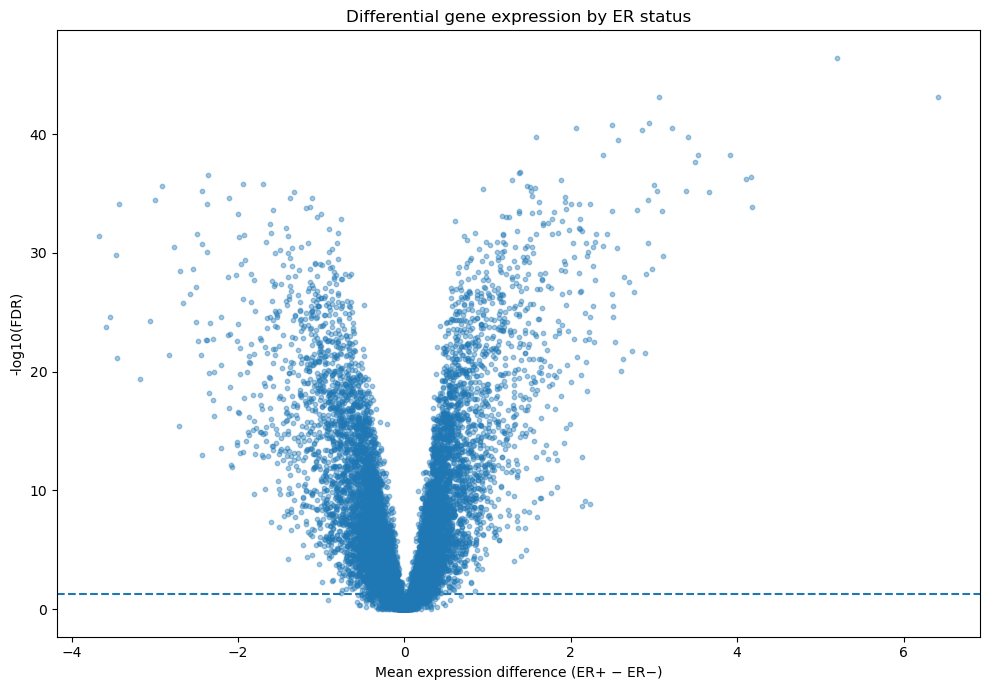

In [72]:
import numpy as np
import matplotlib.pyplot as plt

results["neg_log10_FDR"] = -np.log10(results["FDR"])

plt.figure(figsize=(10, 7))

plt.scatter(
    results["mean_difference"],
    results["neg_log10_FDR"],
    alpha=0.4,
    s=10
)

plt.axhline(
    -np.log10(0.05),
    linestyle="--"
)

plt.xlabel("Mean expression difference (ER+ − ER−)")
plt.ylabel("-log10(FDR)")
plt.title("Differential gene expression by ER status")

plt.tight_layout()
plt.show()

In [69]:
for threshold in [0.25, 0.5, 1.0, 1.5, 2.0]:
    n = (
        (results["FDR"] < 0.05) &
        (results["mean_difference"].abs() >= threshold)
    ).sum()
    
    print(f"|mean difference| >= {threshold}: {n} genes")

|mean difference| >= 0.25: 7448 genes
|mean difference| >= 0.5: 3449 genes
|mean difference| >= 1.0: 950 genes
|mean difference| >= 1.5: 337 genes
|mean difference| >= 2.0: 133 genes


In [70]:
selected_genes = results[
    (results["FDR"] < 0.05) &
    (results["mean_difference"].abs() >= 1)
]["Gene"]

len(selected_genes)

950

In [71]:
results.to_csv("../results/differential_expression_results.csv", index=False)

## Selected Features

The statistical and effect-size criteria identified 950 genes.

This criteria will be used in the machine-learning workflow developed in `02_machine_learning` for downstream analysis.